## Basic examples

Using the conventional `QuantumCircuit` class a la Qiskit.

In [1]:
import numpy as np
from qiskit_from_scratch import QuantumCircuit

# Create a 3-qubit circuit
qc = QuantumCircuit(3, name="MyCircuit")

# Add gates
qc.h(0)  # Hadamard on qubit 0
qc.cx(0, 1)  # CNOT with control=0, target=1
qc.rz(np.pi / 4, 2)  # Z-rotation on qubit 2

# Get the statevector
statevector = qc.state_vector()

/home/iraitz/Documentos/Projects/Mini-Qiskit_with_Tensor_Networks/.venv/lib/python3.12/site-packages/tntorch/cross.py:540: SyntaxWarning: invalid escape sequence '\m'
  """
/home/iraitz/Documentos/Projects/Mini-Qiskit_with_Tensor_Networks/.venv/lib/python3.12/site-packages/tntorch/derivatives.py:205: SyntaxWarning: invalid escape sequence '\i'
  """
/home/iraitz/Documentos/Projects/Mini-Qiskit_with_Tensor_Networks/.venv/lib/python3.12/site-packages/tntorch/metrics.py:120: SyntaxWarning: invalid escape sequence '\g'
  """
/home/iraitz/Documentos/Projects/Mini-Qiskit_with_Tensor_Networks/.venv/lib/python3.12/site-packages/tntorch/metrics.py:136: SyntaxWarning: invalid escape sequence '\g'
  """
/home/iraitz/Documentos/Projects/Mini-Qiskit_with_Tensor_Networks/.venv/lib/python3.12/site-packages/tntorch/metrics.py:155: SyntaxWarning: invalid escape sequence '\g'
  """
/home/iraitz/Documentos/Projects/Mini-Qiskit_with_Tensor_Networks/.venv/lib/python3.12/site-packages/tntorch/metrics.py:248

Implementing for both classical and quantum registries.

In [2]:
from qiskit_from_scratch import QuantumCircuit, QuantumRegister

# Create quantum registers
qx = QuantumRegister(2, name="qx")
qy = QuantumRegister(1, name="qy")

# Create circuit with registers
qc = QuantumCircuit(qx, qy, name="RegisterCircuit")

# Apply gates using register notation
qc.h(qx["all"])  # Hadamard on all qubits in qx
qc.cx(qx[0], qy[0])  # CNOT between registers

MPS representation and compression.

In [3]:
# Create and run circuit with MPS representation
qc = QuantumCircuit(10, name="LargeCircuit")
qc.h(list(range(10)))

# Contract using MPS with compression (eps = error tolerance)
mps = qc.contract(scheme="time", representation="MPS", eps=0.01)

And computing expectation values

In [ ]:
# Create state preparation circuit
qc = QuantumCircuit(3, name="State")
qc.h(0)
qc.cx(0, 1)

# Create operator circuit
operator = QuantumCircuit(3, name="Observable")
operator.z(1)  # Z operator on qubit 1

# Convert operator to gate and compute expectation value
operator_gate = operator.to_gate()
qc.expected(operator_gate, representation="MPS", eps=0.1)

## Visualizing the circuit

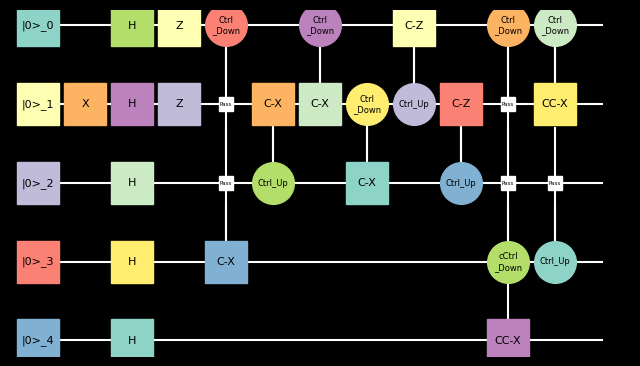

In [7]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Parameters for plots
plt.style.use("dark_background")
rcParams.update({"xtick.labelsize": 25, "ytick.labelsize": 25, "font.size": 30})

# Create quantum register with 5 qubits
qr = QuantumRegister(5, "q")

# Initialize quantum circuit
qc = QuantumCircuit(qr, name="Circuit")

# Apply single-qubit gates
qc.x(qr[1])  # X gate on qubit 1
qc.h(qr["all"])  # Hadamard on all qubits
qc.z(qr[0, 2])  # Z gates on qubits 0 and 2

# Apply two-qubit gates
qc.cx(qr[0], qr[3])  # CNOT: control=0, target=3
qc.cx(qr[2], qr[1])  # CNOT: control=2, target=1
qc.cx(qr[0, 2], qr[1, 3])  # Multiple CNOTs
qc.cz(qr[1, 3], qr[0, 2])  # Controlled-Z gates

# Apply three-qubit gates (Toffoli)
qc.ccx(qr[0], qr[3], qr[4])  # Toffoli: controls=(0,3), target=4
qc.ccx(qr[0], qr[3], qr[1])  # Toffoli: controls=(0,3), target=1

# Display the circuit
print(qc)

In [8]:
qc.state_vector()

Node
(
name : 'state^3_11',
tensor : 
array([[[[[ 0.35355339+0.j,  0.1767767 +0.j],
          [ 0.35355339+0.j,  0.1767767 +0.j]],

         [[ 0.35355339+0.j,  0.1767767 +0.j],
          [-0.35355339+0.j, -0.1767767 +0.j]]],


        [[[ 0.        +0.j,  0.1767767 +0.j],
          [ 0.        +0.j, -0.1767767 +0.j]],

         [[ 0.        +0.j, -0.1767767 +0.j],
          [ 0.        +0.j, -0.1767767 +0.j]]]],



       [[[[ 0.35355339+0.j,  0.1767767 +0.j],
          [ 0.35355339+0.j,  0.1767767 +0.j]],

         [[ 0.35355339+0.j,  0.1767767 +0.j],
          [-0.35355339+0.j, -0.1767767 +0.j]]],


        [[[ 0.        +0.j,  0.1767767 +0.j],
          [ 0.        +0.j, -0.1767767 +0.j]],

         [[ 0.        +0.j, -0.1767767 +0.j],
          [ 0.        +0.j, -0.1767767 +0.j]]]]]),
edges : 
[
Edge(Dangling Edge)[0] 
, 
Edge(Dangling Edge)[1] 
, 
Edge(Dangling Edge)[2] 
, 
Edge(Dangling Edge)[3] 
, 
Edge(Dangling Edge)[4] 
] 
)

Now we will test with an expected value of an operator. For that, we start by creating an operator.

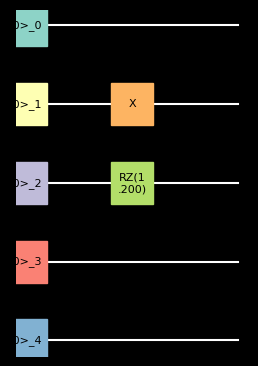

In [9]:
# Create a quantum operator circuit
operator = QuantumCircuit(5, name="Operator")
operator.x(1)
operator.rz(1.2, 2)

# Display the operator circuit
print(operator)

In [10]:
operator_gate = operator.to_gate()

And we introduce it into the circuit

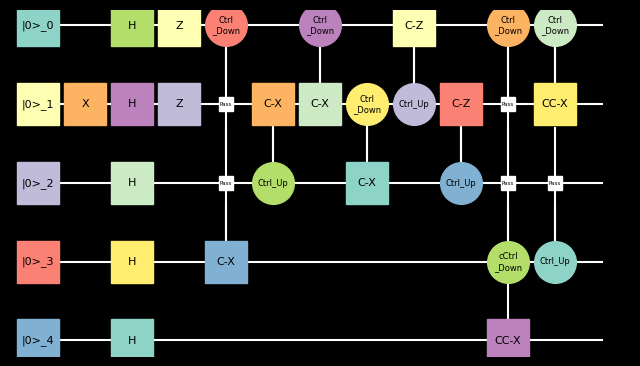

np.complex128(3.3414588882147276e-17-0.5646424733950348j)

In [11]:
# Create quantum register and circuit
qr = QuantumRegister(5, "q")
qc = QuantumCircuit(qr, name="Circuit")

# Apply single-qubit gates
qc.x(qr[1])
qc.h(qr["all"])
qc.z(qr[0, 2])

# Apply two-qubit gates
qc.cx(qr[0], qr[3])
qc.cx(qr[2], qr[1])
qc.cx(qr[0, 2], qr[1, 3])
qc.cz(qr[1, 3], qr[0, 2])

# Apply three-qubit gates (Toffoli)
qc.ccx(qr[0], qr[3], qr[4])
qc.ccx(qr[0], qr[3], qr[1])

# Display the circuit
print(qc)

# Calculate expected value of the operator
qc.expected(operator_gate, representation="statevector", eps=0)